# Unit 2 · Linear models

Course: **21CSC305P — Machine Learning**

## Aim
Use eruption duration to predict the next waiting time, then classify a short or long wait.

## Assignment tasks
1. Implement linear regression to perform prediction.
2. Implement Bayesian logistic regression and SVM for classification.

## About this small dataset
Old Faithful is a geyser: a natural hot spring that sometimes shoots water into the air. This dataset has **299 eruptions and only two measurements**. Each row is one eruption, in the original recorded sequence.

**duration**: how long this eruption lasted, in minutes. **waiting**: how long people waited **before this eruption**, in minutes. There are no missing values, so we do not need to fill or remove them.

Source: [R MASS dataset documentation](https://stat.ethz.ch/R-manual/R-devel/library/MASS/html/geyser.html). Observations were collected August 1-15, 1985. Reference: Azzalini and Bowman (1990), *A look at some data on the Old Faithful geyser*. The supplied original CSV is from the Rdatasets mirror. We removed only its row-number column. Some night-time durations were recorded as 2, 3 or 4 minutes from short/medium/long descriptions.

Run the cells from top to bottom. Keep the `data` folder beside the `notebooks` folder. Learn each step by changing a value and rerunning the cell. These are small classroom demonstrations, not a complete prediction system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/geyser.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/geyser.csv')

print('Number of eruptions:', len(df))

Number of eruptions: 299


## Prepare the prediction problem
The original `waiting` column belongs **before** its eruption. `shift(-1)` takes the following row’s waiting time, so `next_wait` belongs **after** the current eruption. The last row is removed because its next wait is unknown. Only duration is used as the input; `next_wait` is the answer we want to predict.

In [2]:
# The next row's waiting time is the wait AFTER the current eruption.
data = df.copy()
data['next_wait'] = data['waiting'].shift(-1)
data = data.dropna()  # The last eruption has no recorded next wait.

# Keep the first 80% for learning and the final 20% for testing.
split = int(len(data) * 0.8)
train = data.iloc[:split]
test = data.iloc[split:]
print('Training rows:', len(train), '| Testing rows:', len(test))
display(data.head())

Training rows: 238 | Testing rows: 60


,duration,waiting,next_wait
0,4.016667,80,71.0
1,2.150000,71,57.0
2,4.000000,57,80.0
3,4.000000,80,75.0
4,4.000000,75,77.0


## Experiment 1 · Linear regression
Fit a straight line: next waiting time = slope × duration + intercept. `fit()` learns from training rows; `predict()` gives answers for new rows.

Slope: 10.61
Intercept: 35.5
Mean absolute error: 5.28 minutes


,actual,predicted
0,80.0,82.72
1,89.0,80.78
2,45.0,55.84
3,93.0,82.37
4,72.0,67.33


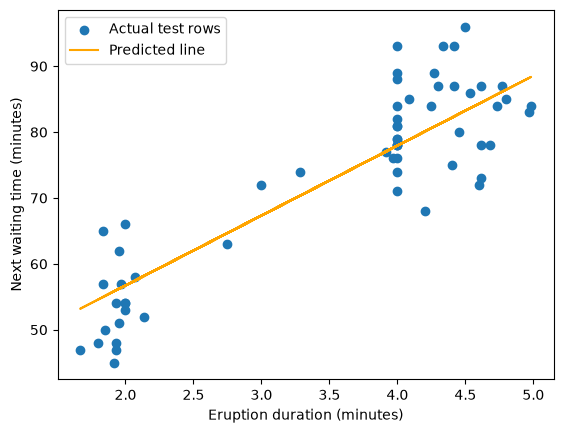

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(train[['duration']], train['next_wait'])
predicted_wait = model.predict(test[['duration']])
print('Slope:', round(model.coef_[0], 2))
print('Intercept:', round(model.intercept_, 2))
print('Mean absolute error:', round(mean_absolute_error(test['next_wait'], predicted_wait), 2), 'minutes')
display(pd.DataFrame({'actual': test['next_wait'].to_numpy()[:5], 'predicted': predicted_wait[:5]}).round(2))

plt.scatter(test['duration'], test['next_wait'], label='Actual test rows')
plt.plot(test['duration'], predicted_wait, color='orange', label='Predicted line')
plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Next waiting time (minutes)')
plt.legend()
plt.show()

## Prepare classification
We turn the target into two categories: **0 = short wait**, **1 = long wait**. Scaling centers the input around zero. Learn the scaler from training rows only.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# A long wait means 70 minutes or more. This is our classroom rule.
X_train = train[['duration']]
X_test = test[['duration']]
y_train = (train['next_wait'] >= 70).astype(int).to_numpy()
y_test = (test['next_wait'] >= 70).astype(int).to_numpy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Class 0 = wait below 70 minutes; class 1 = wait at least 70 minutes')

Class 0 = wait below 70 minutes; class 1 = wait at least 70 minutes


## Experiment 2a · Bayesian logistic regression
A logistic curve turns a number into a probability. We try a small grid of intercepts and slopes, give each a Gaussian prior, and calculate how well it explains the training labels. We then average the curves using their posterior weights. This is a simple **grid approximation to Bayesian inference**, using just one input and two parameters. The grid is finite, so the answer is approximate.

In [5]:
x_train = X_train_scaled[:, 0]
x_test = X_test_scaled[:, 0]
parameters = []
scores = []

# Try different intercepts and slopes for the logistic curve.
for intercept in np.linspace(-6, 6, 41):
    for slope in np.linspace(-6, 6, 41):
        probability = 1 / (1 + np.exp(-(intercept + slope * x_train)))
        likelihood = np.sum(y_train * np.log(probability + 1e-12)
                            + (1 - y_train) * np.log(1 - probability + 1e-12))
        prior = -(intercept**2 + slope**2) / 8  # Gaussian prior: variance 4
        parameters.append([intercept, slope])
        scores.append(likelihood + prior)

# Convert scores into posterior weights that add up to one.
weights = np.exp(np.array(scores) - np.max(scores))
weights = weights / weights.sum()
bayes_probability = np.zeros(len(x_test))
for weight, (intercept, slope) in zip(weights, parameters):
    probability = 1 / (1 + np.exp(-(intercept + slope * x_test)))
    bayes_probability += weight * probability

bayes_prediction = (bayes_probability >= 0.5).astype(int)
print('Bayesian logistic accuracy:', round(accuracy_score(y_test, bayes_prediction), 3))

Bayesian logistic accuracy: 0.967


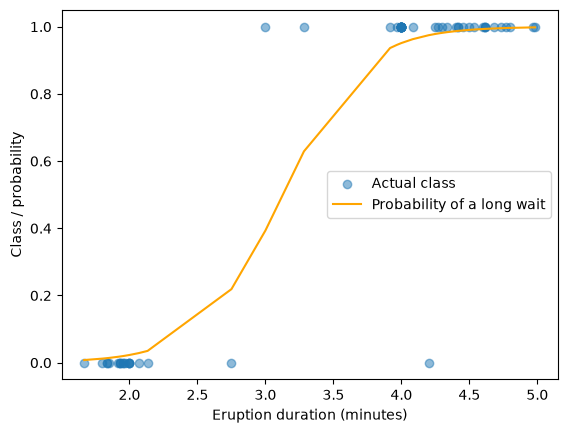

In [6]:
order = np.argsort(test['duration'].to_numpy())
plt.scatter(test['duration'], y_test, label='Actual class', alpha=0.5)
plt.plot(test['duration'].to_numpy()[order], bayes_probability[order], color='orange', label='Probability of a long wait')
plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Class / probability')
plt.legend()
plt.show()

## Experiment 2b · SVM
An SVM finds a boundary between classes. With one input and a linear kernel, the boundary is a cutoff along the duration axis.

SVM accuracy: 0.967


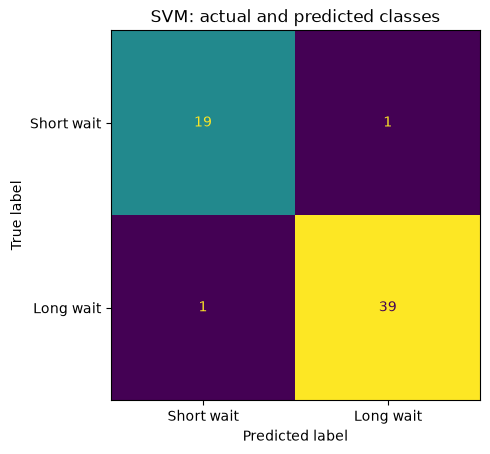

In [7]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)
svm_prediction = svm.predict(X_test_scaled)
print('SVM accuracy:', round(accuracy_score(y_test, svm_prediction), 3))
ConfusionMatrixDisplay.from_predictions(y_test, svm_prediction, display_labels=['Short wait', 'Long wait'], colorbar=False)
plt.title('SVM: actual and predicted classes')
plt.show()

## What to explain
Regression predicts a number; classification predicts a category. An error of 5 minutes means a numerical prediction was 5 minutes away from its actual value. The Bayesian model uses a prior and averages several possible curves. We do not adjust model settings after seeing test results.

**Try:** Predict the next waiting time for a 2-minute eruption using `model.predict(pd.DataFrame({"duration": [2]}))`.

**Viva:** What are input and target? What is a prior? What does accuracy measure?